# Using Masimo's Algorithm on Normalized Derivative Time Series
In this notebook, we test out Masimo's algorithm on normalized derivaties calculated off of different TFO PPG probe data. We try this out across some time window to determine if the R predicted from the algorithm does track saturation. (Or if there is atleast some sort of a trend) 

## Preprocessing Steps
1. The normalized derivative produces some very wild outlier points. Clipping the outputs at 5 and 95 percentile
2. Filter around 1.5Hz 
3. Moving avg. 

## Preliminary Results
Does not work. I do not see the usual streak along time at/ around a certain R. The R peaks are spreaded all throughout!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from TFO_dataset import SheepData
from tfo_masimo.preprocessing.custom_preprocessing import normalized_derivative
from tfo_masimo.preprocessing.adaptive_filters import adaptive_filter_lms, adaptive_filter_rls
from tfo_masimo.visualization.spectrograms import generate_spectrogram, get_manipulated_stft_inverse_kaiser
from scipy.signal import get_window
from scipy.stats.mstats import winsorize


In [2]:
# Load data
tag = {'experiment_number': 5,
       'experiment_round': 2,
       'experiment_year_prefix': 'sp2022',
       'additional_info': ''}
FS = 80
ppg = SheepData('iq_demod_optical').get_data_from_tag(tag).to_numpy() # 80Hz
# sao2 = SheepData('fSaO2').get_available_tags()
saturation = SheepData('fSaO2').get_data_from_tag(tag).to_numpy().flatten()  # 1Hz

# Crop to equal length
min_len = min(len(saturation) * FS, len(ppg))
ppg = ppg[:min_len, :]
saturation = saturation[:min_len//FS]

# Time Axis
saturation_timeline = np.arange(0, stop=min_len // FS, step=1)
ppg_timeline = np.arange(0, stop=min_len // FS, step=1/FS)

In [3]:
%matplotlib widget

In [4]:
DERIVATIVE_PADDING_SAMPLE_COUNT = 100
DETECTOR_ID = 3     # 0 to 4
_, rd = normalized_derivative(ppg[:, DETECTOR_ID])
_, ir = normalized_derivative(ppg[:, DETECTOR_ID + 5])
rd = rd[DERIVATIVE_PADDING_SAMPLE_COUNT:-DERIVATIVE_PADDING_SAMPLE_COUNT]
ir = ir[DERIVATIVE_PADDING_SAMPLE_COUNT:-DERIVATIVE_PADDING_SAMPLE_COUNT]

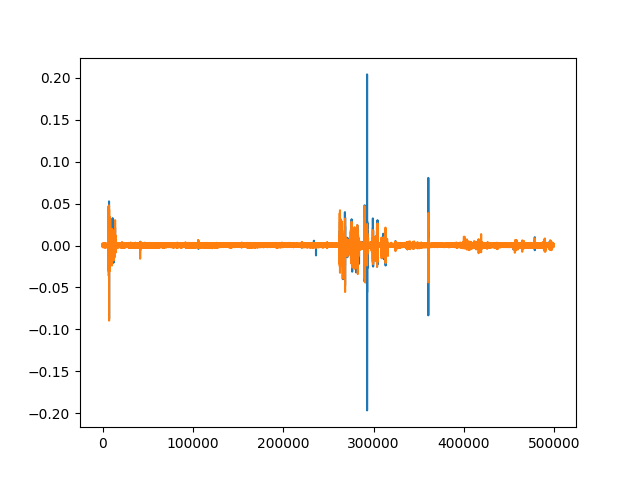

In [5]:
plt.figure()
plt.plot(rd, label='RD')
plt.plot(ir, label='IR')

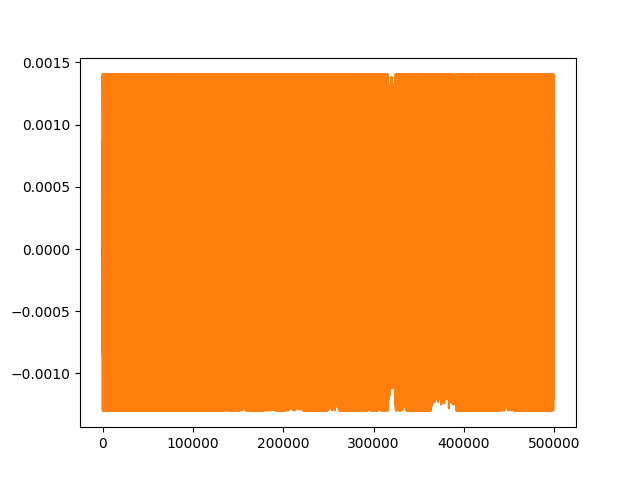

In [6]:
# MA
MA_FILTER_LENGTH = 30
ir = np.convolve(ir, np.ones((MA_FILTER_LENGTH,)), mode='valid') / MA_FILTER_LENGTH
rd = np.convolve(rd, np.ones((MA_FILTER_LENGTH,)), mode='valid') / MA_FILTER_LENGTH
# Outlier
ir = winsorize(ir, [0.05, 0.05 ])
rd = winsorize(rd, [0.05, 0.05 ])

plt.figure()
plt.plot(rd, label='RD (Filtered)')
plt.plot(ir, label='IR (Filtered)')

In [7]:
# Spectrum Filtering
ir = get_manipulated_stft_inverse_kaiser(ir, [1.5], window_length=30, fhr_bins_to_keep= 10, fs=FS)
rd = get_manipulated_stft_inverse_kaiser(rd, [1.5], window_length=30, fhr_bins_to_keep= 10, fs=FS)

## Signal Spectrum
Masmim'o algorithm is essentially based on filtering the signal based on their spectrums. If the spectrum itself is not clean, I do not expect the rest of the things to work out

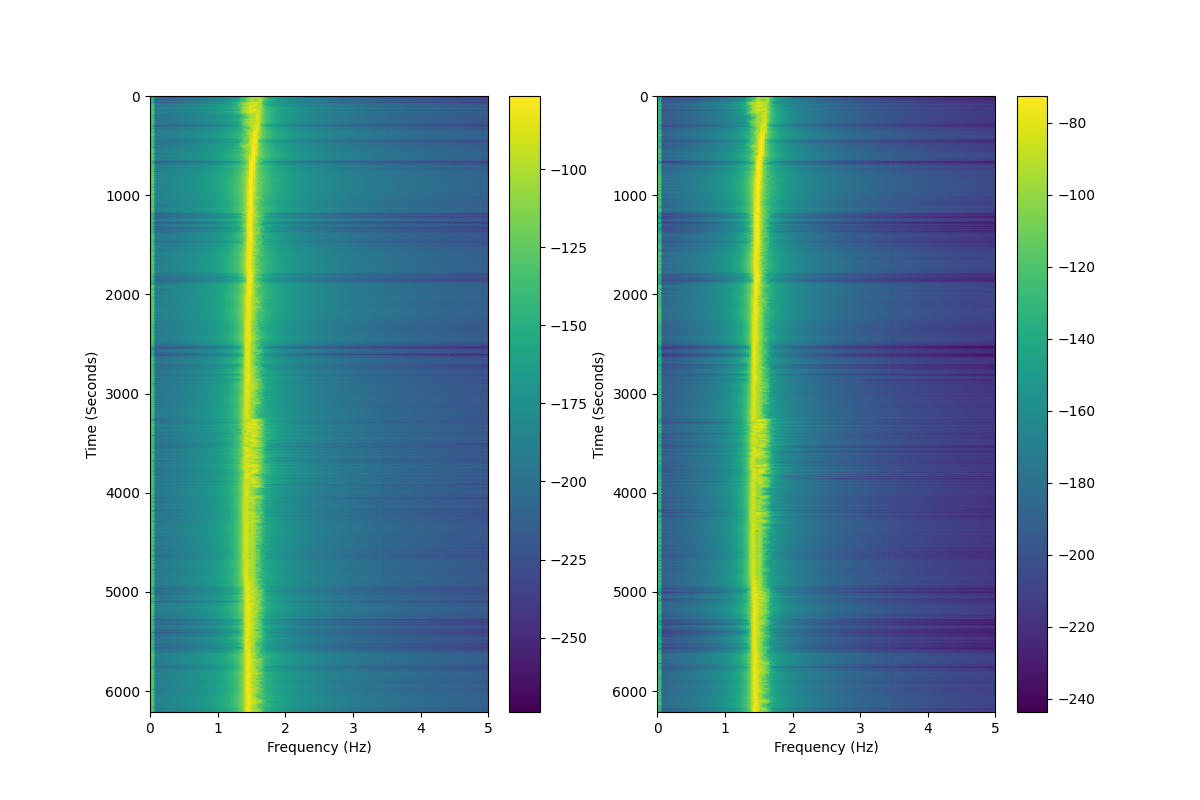

In [8]:
rd_spectrogram = generate_spectrogram(rd, FS, window_length=30, overlap_percent=3/4)
ir_spectrogram = generate_spectrogram(ir, FS, window_length=30, overlap_percent=3/4)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
rd_spectrogram.plot([0, 5])
plt.colorbar()

plt.subplot(1, 2, 2)
ir_spectrogram.plot([0, 5])
plt.colorbar()
plt.show()

## Masimo Alg.

In [9]:
# Filter Params
n = 100
# forgetting_factor = 1 - 1 / (40 * FS)
forgetting_factor = 0.1

# Watning : This part takes a while
peak_r = []
energy_map = []
r_time_axis = []
window_length = 80 * FS  # 80s
overlap_percnt = 0.3

r_values_fetal = np.arange(4, 15, step=0.4)
# r_values_fetal = np.arange(0.3, 1.0, step=0.05)

for i in range(120):
    starting_sample = int(i * window_length * overlap_percnt)
    ending_sample = int(starting_sample + window_length)
    if ending_sample > len(rd):
        break
    r_time_axis.append((starting_sample + ending_sample) // 2 * 1 / FS)  # Plotting this data at the time in the middle

    # Filtered/ Reconstructed RD and IR signals
    filtered_rd = rd[starting_sample: ending_sample]
    filtered_ir = ir[starting_sample: ending_sample]

    # Start sweeping through r
    # Sweep For Fetal
    calculated_energies_fetal = []

    # Residual plots
    # fig, axes = plt.subplots(2, 5)
    # axes = axes.flatten()

    for index, r in enumerate(r_values_fetal):
        rs = r * filtered_ir - filtered_rd
        _, residual, __ = adaptive_filter_lms(rs, filtered_ir, filter_length=n, filter_lambda=forgetting_factor)
        # residual = filtered_ir - rs

        residual = residual[25 * FS:]  # Drop unstable part of the data
        residual = residual * get_window('hann', len(residual))
        # axes[index].plot(residual)
        # axes[index].set_xlabel(f"r = {r}")
        energy = np.mean(residual * residual)
        # Window is being calculated each time (since residual might be of different length)
        calculated_energies_fetal.append(energy)  # Assuming it takes at least 20 samples to stabilize
    max_energy = max(calculated_energies_fetal)
    max_energy_index = calculated_energies_fetal.index(max_energy)
    peak_r.append(r_values_fetal[max_energy_index])
    # energy_map.append(np.array(calculated_energies_fetal) / max_energy)  # Normalized Energy per window
    energy_map.append(np.array(calculated_energies_fetal)/ max(calculated_energies_fetal))  # Debug path with no normalization


Text(0.5, 0, 'Time (s)')

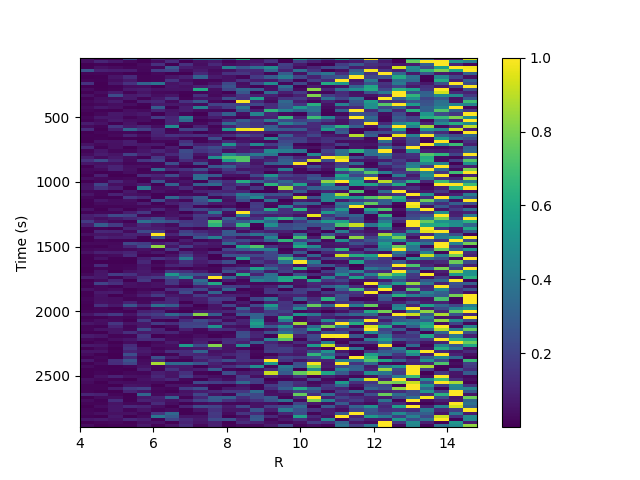

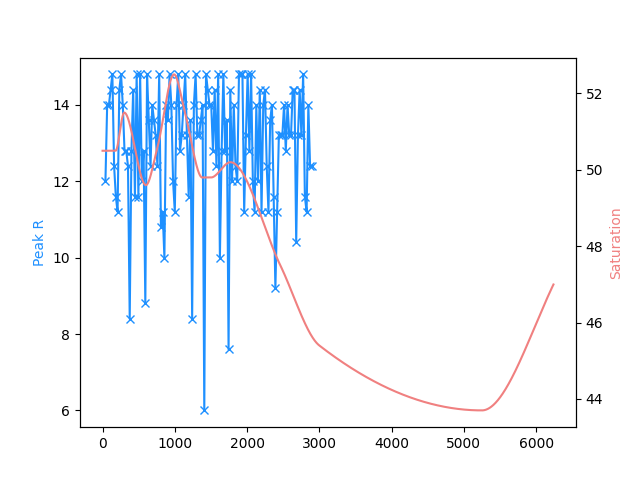

In [10]:
plt.figure()
energy_map = np.array(energy_map)
energy_map = energy_map / np.max(energy_map)
plt.imshow(energy_map, extent=[r_values_fetal[0], r_values_fetal[-1], r_time_axis[-1], r_time_axis[0]],
           interpolation=None, aspect="auto")
plt.xlabel('R')
plt.ylabel('Time (s)')
plt.colorbar()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(r_time_axis, peak_r, 'x-', color='dodgerblue')
ax1.set_ylabel('Peak R')
ax1.yaxis.label.set_color('dodgerblue')

ax2.plot(saturation_timeline, saturation, color='lightcoral')
ax2.set_ylabel('Saturation')
ax2.yaxis.label.set_color('lightcoral')

ax2.set_xlabel("Time (s)")